In [1]:
pip install pandas scikit-learn nltk matplotlib seaborn


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!



Classification Report:
              precision    recall  f1-score   support

          ☹️       0.96      0.96      0.96     26675
           🙂       0.96      0.96      0.96     29890

    accuracy                           0.96     56565
   macro avg       0.96      0.96      0.96     56565
weighted avg       0.96      0.96      0.96     56565



/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 128578 (\N{SLIGHTLY SMILING FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128578 (\N{SLIGHTLY SMILING FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


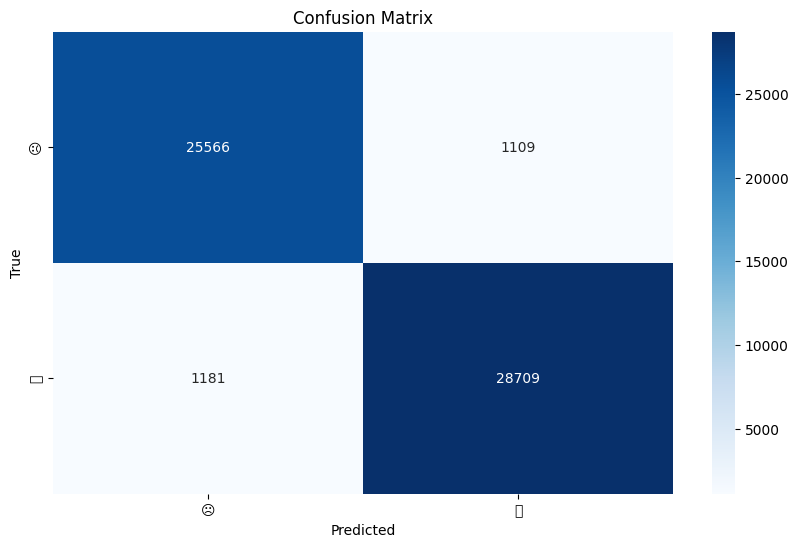

Text: I can't believe how amazing this day has been!
Predicted Emotion: 🙂
Text: This is so frustrating and annoying.
Predicted Emotion: ☹️


In [4]:
# social_media_monitoring.py

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
import nltk
from nltk.corpus import stopwords
import re

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

df = pd.read_csv('/content/Text_Emotion.csv.zip')

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\@w+|\#','', text)
    text = re.sub(r'[^A-Za-z\s]', '', text)
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

df['clean_text'] = df['text'].apply(clean_text)

X = df['clean_text']
y = df['emotion']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('clf', LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(10,6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=model.classes_, yticklabels=model.classes_, cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

def monitor_emotion(text):
    cleaned = clean_text(text)
    prediction = model.predict([cleaned])[0]
    print(f"Text: {text}")
    print(f"Predicted Emotion: {prediction}")

# Example
monitor_emotion("I can't believe how amazing this day has been!")
monitor_emotion("This is so frustrating and annoying.")